In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df =pd.read_csv("/content/drive/MyDrive/Colab Notebooks/studentperformance_preproccesed.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   str    
 1   race/ethnicity               1000 non-null   str    
 2   parental level of education  1000 non-null   str    
 3   lunch                        1000 non-null   str    
 4   test preparation course      1000 non-null   str    
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Total Score                  1000 non-null   int64  
 9   percentage                   1000 non-null   float64
dtypes: float64(1), int64(4), str(5)
memory usage: 78.3 KB


In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Total Score', 'percentage'],
      dtype='str')

In [ ]:
df.shape

(1000, 10)

In [ ]:
score_columns=['math score','reading score','writing score',]

In [ ]:
df[score_columns].head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [ ]:
demographic_columns = ['gender','race/ethnicity','parental level of education','lunch','test preparation course']

In [ ]:
df[demographic_columns].head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


In [ ]:
df['gender'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [ ]:
df['parental level of education'].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

In [ ]:
df['lunch'].unique()

<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

In [ ]:
df['test preparation course'].unique()

<StringArray>
['none', 'completed']
Length: 2, dtype: str

## 1. Grouped bar charts

In [ ]:
parental_scores = df.groupby('parental level of education')[score_columns].mean()
parental_scores

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


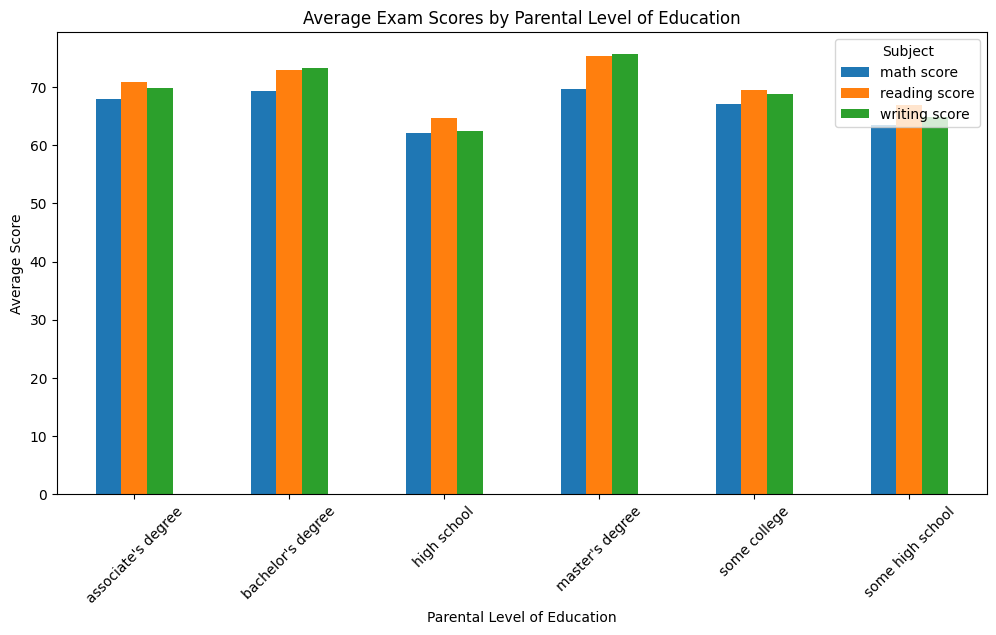

In [ ]:
parental_scores.plot(kind='bar',figsize=(12,6))
plt.title('Average Exam Scores by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Subject')
plt.show()

In [ ]:
lunch_scores = df.groupby('lunch')[score_columns].mean()
lunch_scores

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


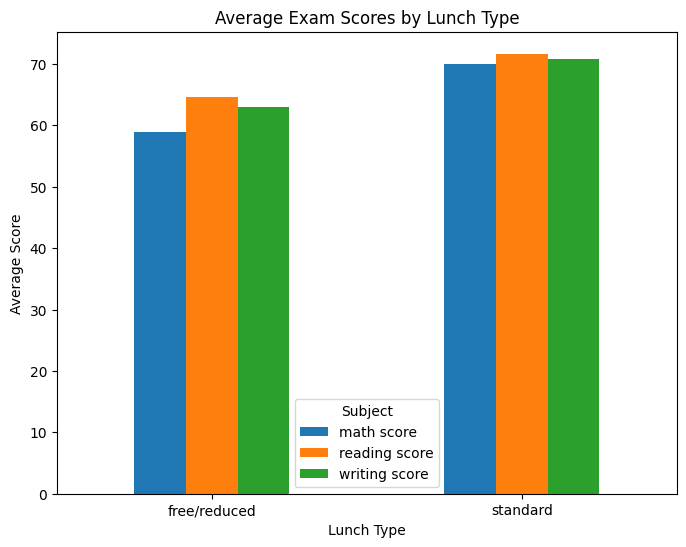

In [ ]:
lunch_scores.plot(kind='bar',figsize=(8,6))
plt.title('Average Exam Scores by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.show()

Parental education and lunch type together.

In [ ]:
edu_order = ['some high school','high school','some college',"associate's degree","bachelor's degree","master's degree"]

In [ ]:
math_scores = df.pivot_table(index='parental level of education', columns='lunch', values='math score', aggfunc='mean').reindex(edu_order)
math_scores

lunch,free/reduced,standard
parental level of education,,
some high school,53.934426,68.440678
high school,54.514286,66.373016
some college,60.126582,70.891156
associate's degree,62.610390,70.682759
bachelor's degree,63.000000,73.189189
master's degree,61.166667,75.628571


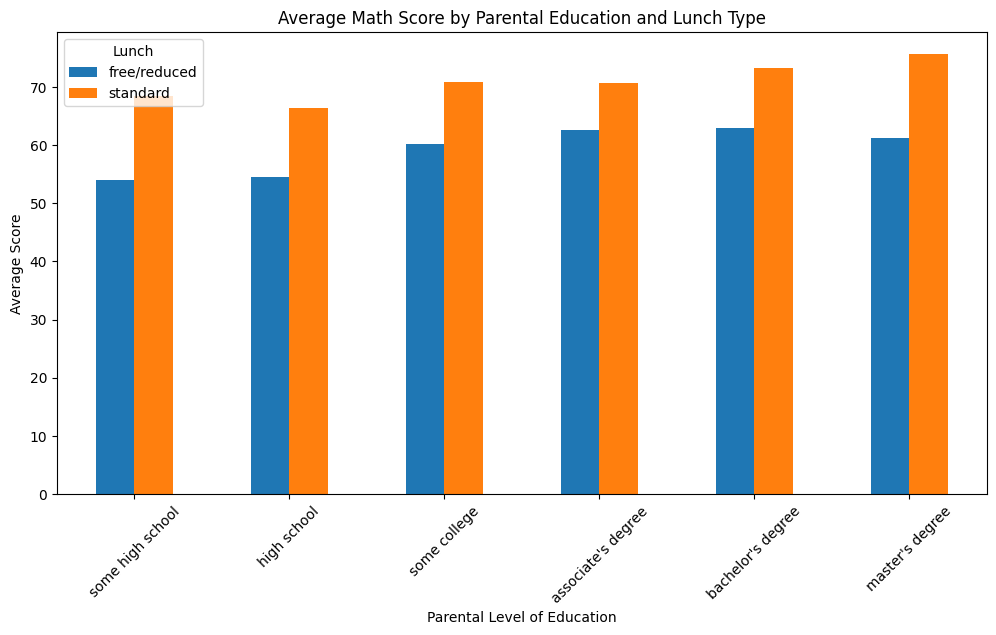

In [ ]:
math_scores.plot(kind='bar',figsize=(12,6))
plt.title('Average Math Score by Parental Education and Lunch Type')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Lunch', loc='upper left')
plt.show()

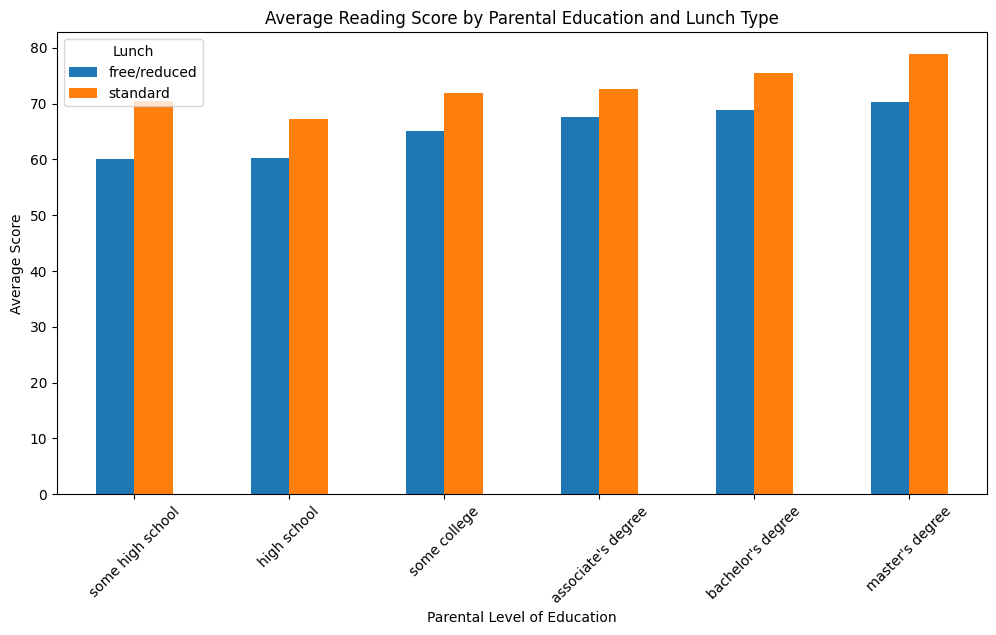

In [ ]:
reading_scores = df.pivot_table(index='parental level of education', columns='lunch', values='reading score', aggfunc='mean').reindex(edu_order)
reading_scores.plot(kind='bar',figsize=(12,6))
plt.title('Average Reading Score by Parental Education and Lunch Type')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Lunch', loc='upper left')
plt.show()

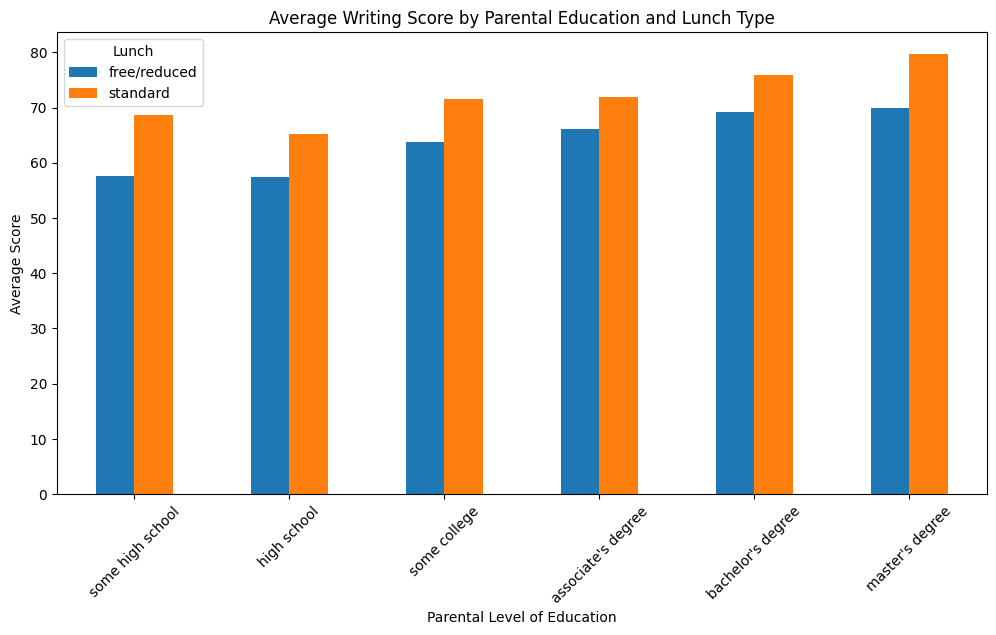

In [ ]:
writing_scores = df.pivot_table(index='parental level of education', columns='lunch', values='writing score', aggfunc='mean').reindex(edu_order)
writing_scores.plot(kind='bar',figsize=(12,6))
plt.title('Average Writing Score by Parental Education and Lunch Type')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Lunch', loc='upper left')
plt.show()

In [ ]:
percentage_scores = df.pivot_table(index='parental level of education', columns='lunch', values='percentage', aggfunc='mean').reindex(edu_order)
percentage_scores

lunch,free/reduced,standard
parental level of education,,
some high school,57.224044,69.183616
high school,57.376190,66.275132
some college,62.970464,71.435374
associate's degree,65.428571,71.767816
bachelor's degree,67.053030,74.819820
master's degree,67.111111,78.047619


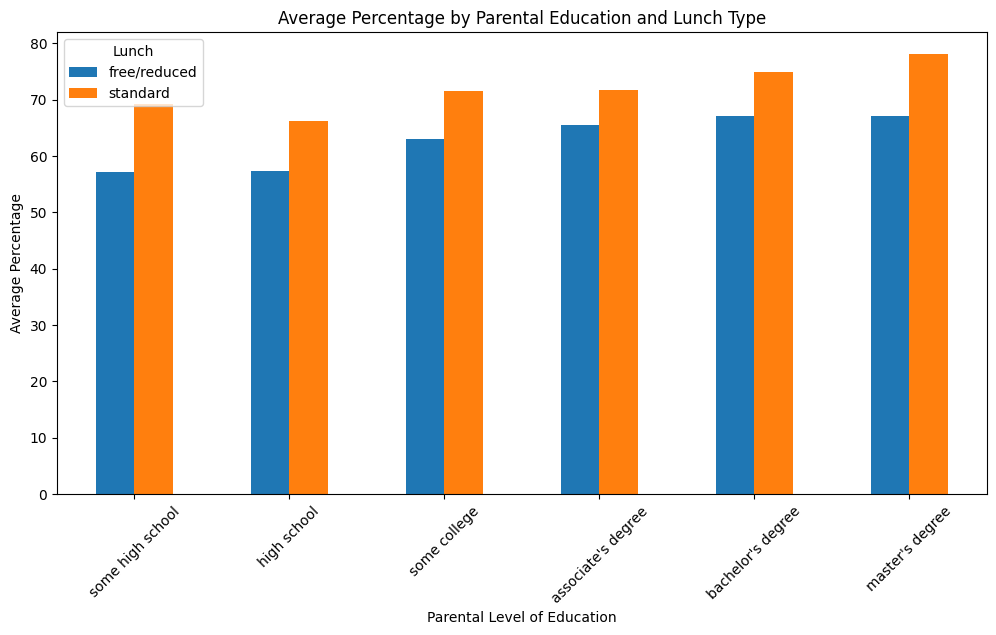

In [ ]:
percentage_scores.plot(kind='bar',figsize=(12,6))
plt.title('Average Percentage by Parental Education and Lunch Type')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Percentage')
plt.xticks(rotation=45)
plt.legend(title='Lunch', loc='upper left')
plt.show()

## 2. Box plots: test preparation

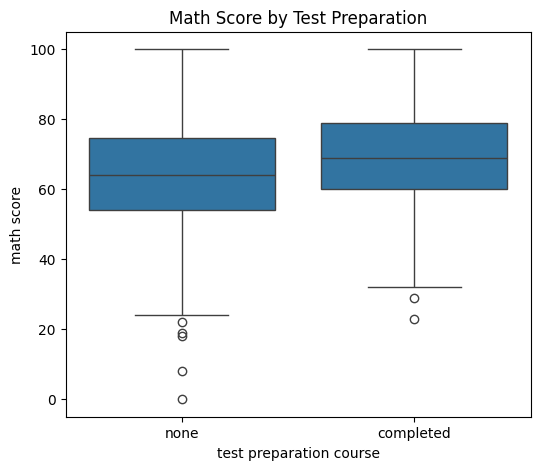

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title('Math Score by Test Preparation')
plt.show()

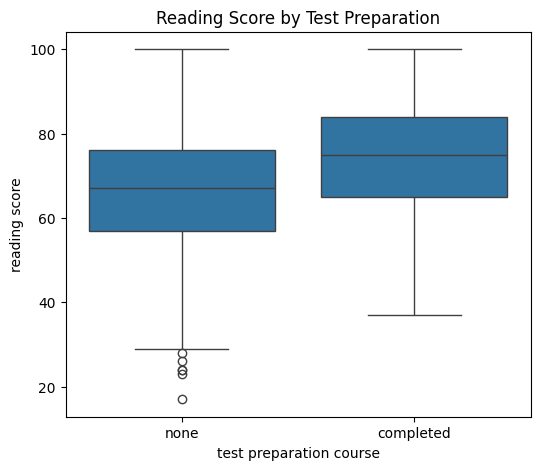

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='test preparation course', y='reading score', data=df)
plt.title('Reading Score by Test Preparation')
plt.show()

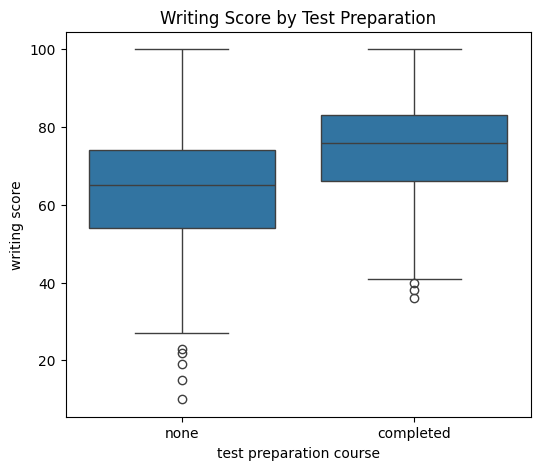

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='test preparation course', y='writing score', data=df)
plt.title('Writing Score by Test Preparation')
plt.show()

In [ ]:
df.groupby('test preparation course')[score_columns].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [ ]:
df.groupby('test preparation course')[score_columns].std()

,math score,reading score,writing score
test preparation course,,,
completed,14.444699,13.638384,13.375335
none,15.192376,14.463885,14.999661


In [ ]:
df.groupby('test preparation course')[score_columns].var()

,math score,reading score,writing score
test preparation course,,,
completed,208.649336,186.005508,178.899582
none,230.808278,209.203972,224.989838


## 3. Scatter plots and correlation heatmap

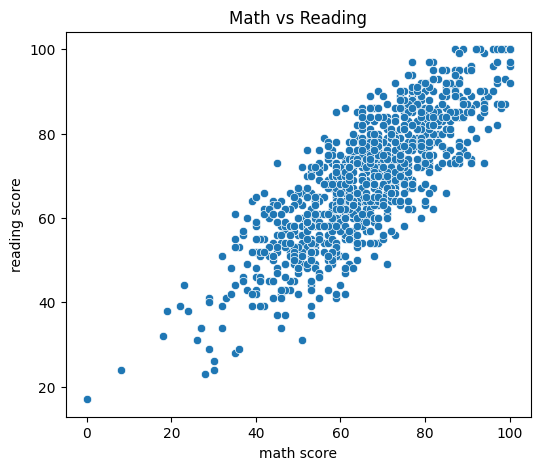

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='math score', y='reading score', data=df)
plt.title('Math vs Reading')
plt.show()

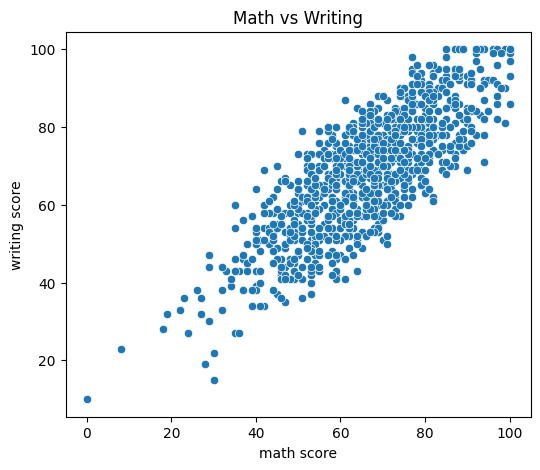

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='math score', y='writing score', data=df)
plt.title('Math vs Writing')
plt.show()

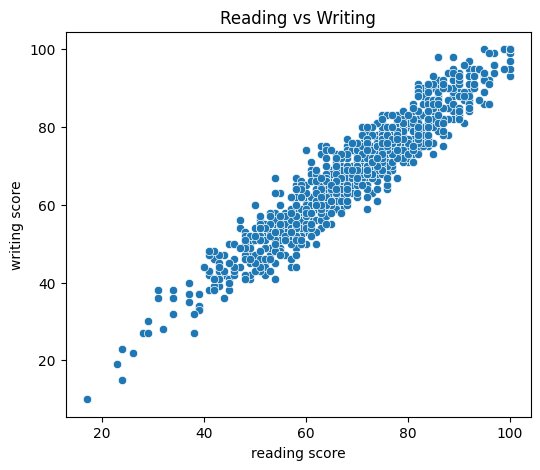

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title('Reading vs Writing')
plt.show()

In [ ]:
df[score_columns].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


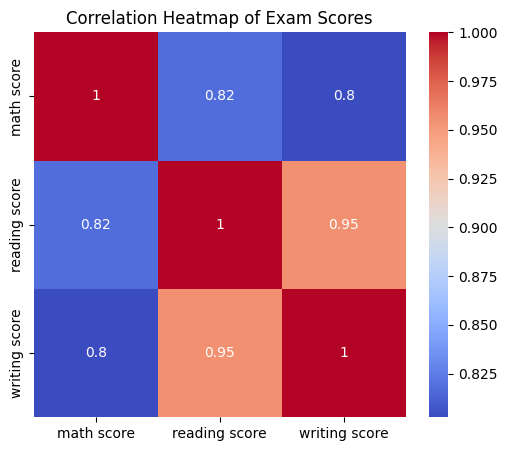

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df[score_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Exam Scores')
plt.show()